# Dataset description
## Child labor by sex

**Source**: DANE

**Dataset**: [GEIH](https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/trabajo-infantil)

# Code
## Imports

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

## Load data

In [50]:
path = "./data/sexo.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [51]:
df_f = df[
    (df["Fecha"].eq(2025)) &
    (df["Perspectiva"].eq("Total nacional")) &
    (df["Concepto"].str.contains("trabajan"))
]

df_f.loc[:, "Concepto"] = df_f["Concepto"].str.split("que ", n=1).str[1]

table = df_f.pivot_table(
    index="Sexo",
    columns="Concepto",
    values="Valor"
)
table = table.reindex(columns=["trabajan", "no trabajan y realizan trabajo doméstico no remunerado en su hogar por 15 horas o más", "no trabajan y realizan trabajo doméstico y de cuidado no remunerado en su hogar por 15 horas o más"])

## Plot

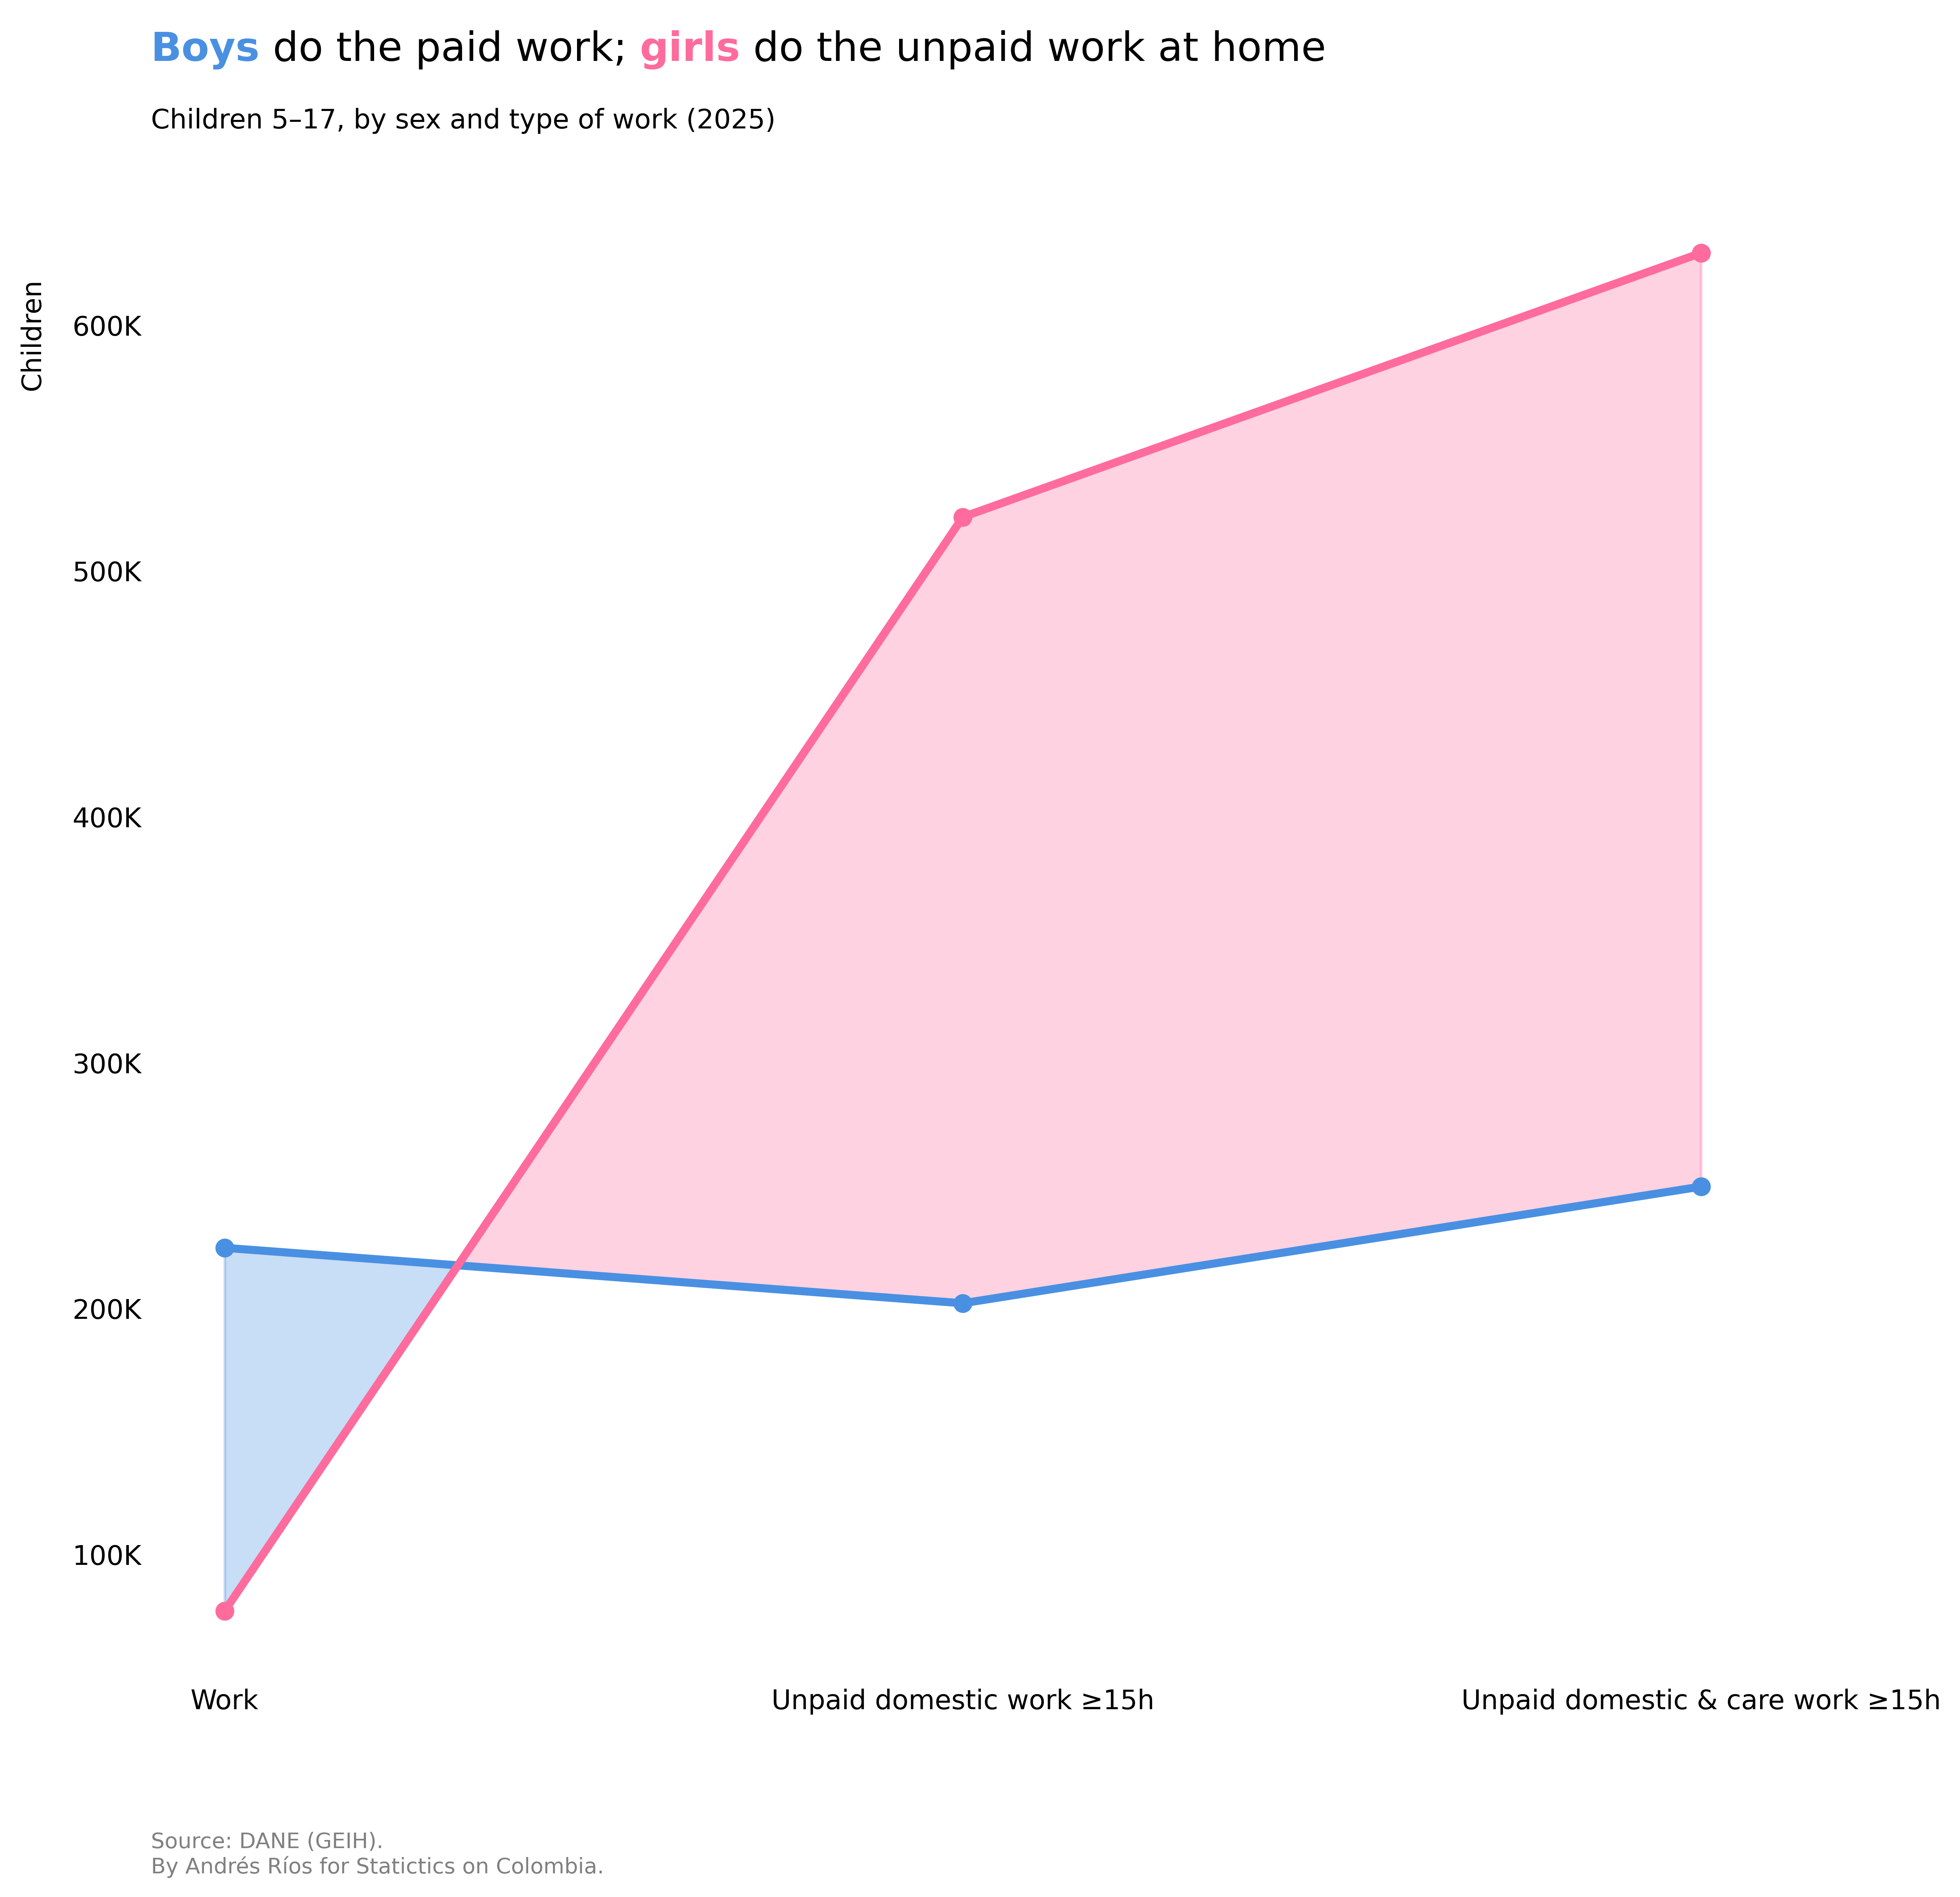

In [63]:
labels = ["Work", "Unpaid domestic work ≥15h", "Unpaid domestic & care work ≥15h"]
men = table.loc["Hombres", :]
women = table.loc["Mujeres", :]
men_color = "#4A90E2" 
women_color = "#FF6B9D" 

plt.figure(figsize=(10.8, 10), dpi=500)

plt.plot(labels, men, color=men_color, marker="o", linewidth=3)
plt.plot(labels, women, color=women_color, marker="o", linewidth=3)

plt.fill_between(labels, men, women, where=(men >= women), alpha=0.3, color=men_color, interpolate=True)
plt.fill_between(labels, men, women, where=(women > men), alpha=0.3, color=women_color, interpolate=True)


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}K"))

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Children", labelpad=10, fontsize=10, y=0.9)

fig_text(
    0.125, 0.96,
    s="<Boys> do the paid work; <girls> do the unpaid work at home",
    highlight_textprops=[{"color": men_color, "weight": "bold"},
                        {"color": women_color, "weight": "bold"}],
    fontsize=15,
)

fig_text(
    0.125, 0.92,
    s="Children 5–17, by sex and type of work (2025)",
    fontsize=10,
)

fig = plt.gcf()
fig.text(
    0.125, 0.01, 
    "Source: DANE (GEIH).\n"
    "By Andrés Ríos for Statictics on Colombia.", 
    fontsize=8, color="gray",
)

plt.show()